In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.shape

(1025, 14)

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(302, 14)

In [11]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    print(col, sorted(df[col].unique()))

sex [np.int64(0), np.int64(1)]
cp [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs [np.int64(0), np.int64(1)]
restecg [np.int64(0), np.int64(1), np.int64(2)]
exang [np.int64(0), np.int64(1)]
slope [np.int64(0), np.int64(1), np.int64(2)]
ca [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
thal [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [12]:
df['ca'].value_counts()

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

In [13]:
df['thal'].value_counts()

thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64

In [14]:
df = df[(df['ca'] != 4) & (df['thal'] != 0)]

In [15]:
df.shape

(296, 14)

In [16]:
df['target'].value_counts()

target
1    160
0    136
Name: count, dtype: int64

In [17]:
df['target'].value_counts(normalize=True)

target
1    0.540541
0    0.459459
Name: proportion, dtype: float64

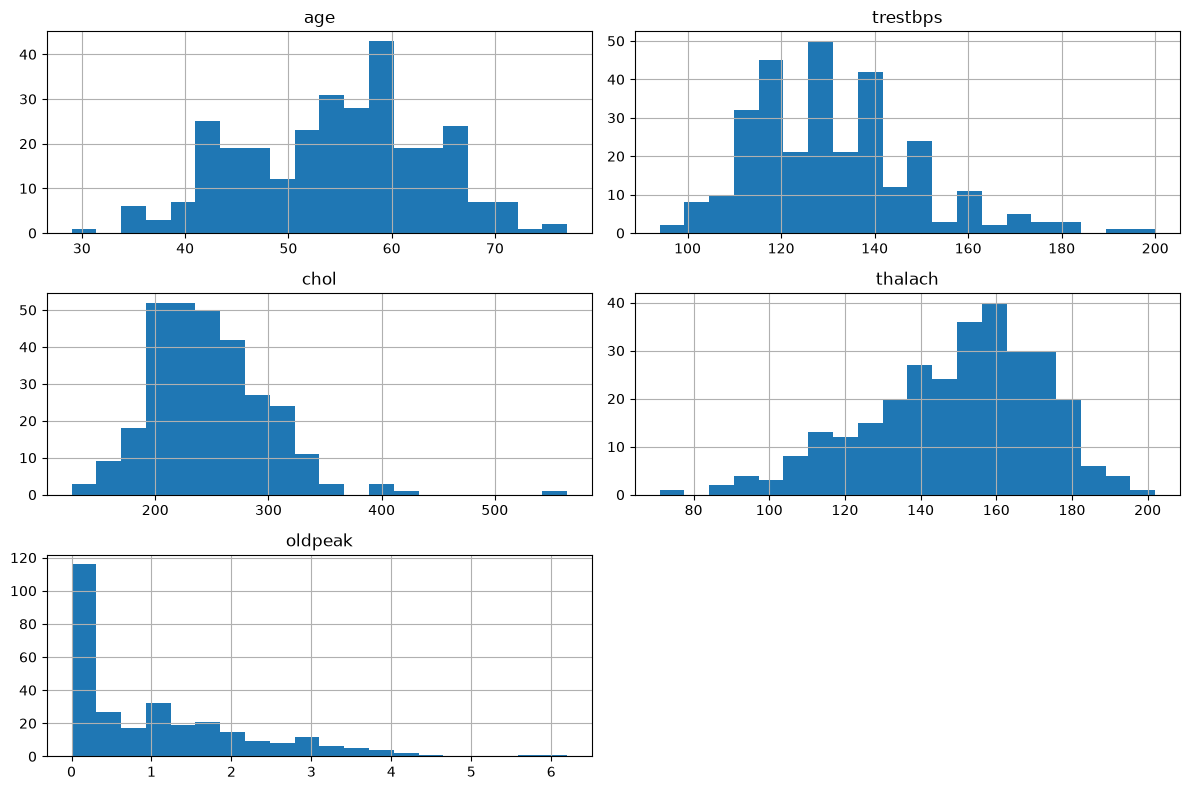

In [18]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

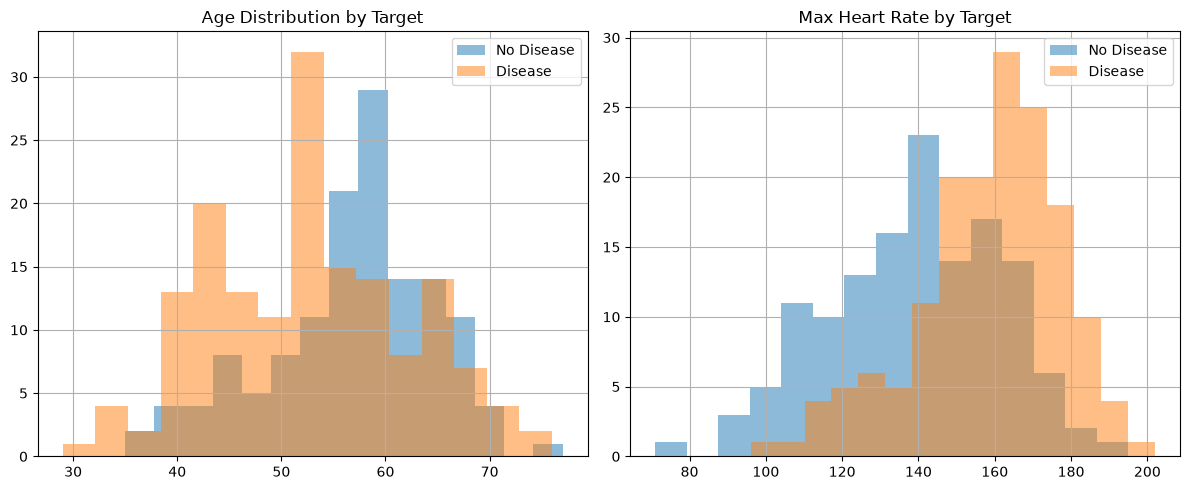

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df[df['target']==0]['age'].hist(alpha=0.5, label='No Disease', ax=axes[0], bins=15)
df[df['target']==1]['age'].hist(alpha=0.5, label='Disease', ax=axes[0], bins=15)
axes[0].set_title('Age Distribution by Target')
axes[0].legend()
df[df['target']==0]['thalach'].hist(alpha=0.5, label='No Disease', ax=axes[1], bins=15)
df[df['target']==1]['thalach'].hist(alpha=0.5, label='Disease', ax=axes[1], bins=15)
axes[1].set_title('Max Heart Rate by Target')
axes[1].legend()
plt.tight_layout()
plt.show()

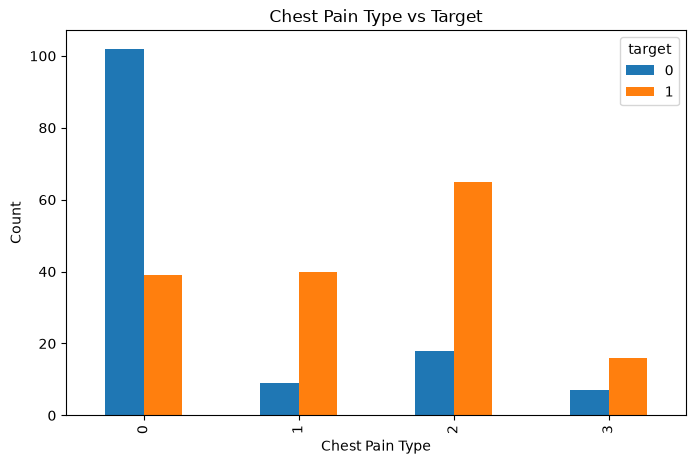

In [20]:
pd.crosstab(df['cp'], df['target']).plot(kind='bar', figsize=(8,5))
plt.title('Chest Pain Type vs Target')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

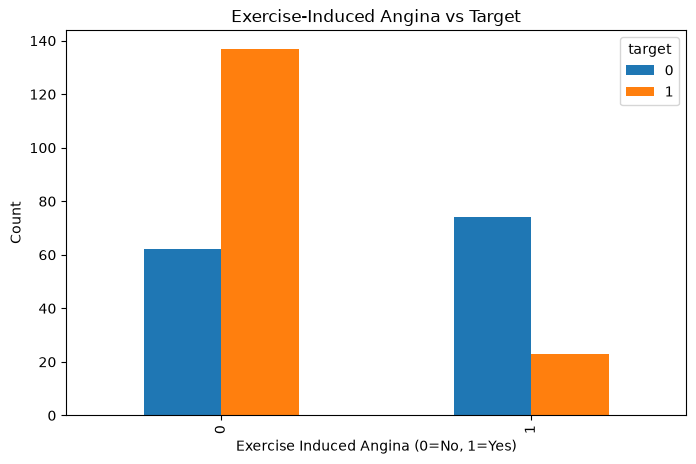

In [21]:
pd.crosstab(df['exang'], df['target']).plot(kind='bar', figsize=(8,5))
plt.title('Exercise-Induced Angina vs Target')
plt.xlabel('Exercise Induced Angina (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

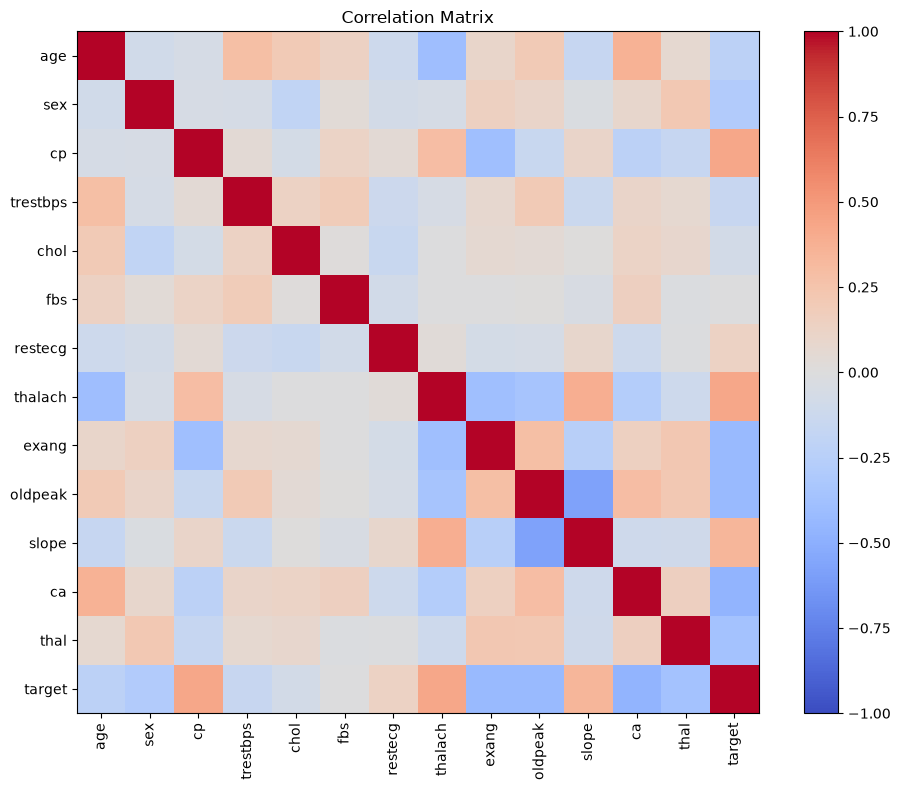

In [22]:
corr = df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [23]:
df.corr()['target'].sort_values(ascending=False)

target      1.000000
thalach     0.426655
cp          0.423425
slope       0.337825
restecg     0.131716
fbs        -0.004680
chol       -0.076541
trestbps   -0.148922
age        -0.225453
sex        -0.285322
thal       -0.364399
exang      -0.425085
oldpeak    -0.428804
ca         -0.467158
Name: target, dtype: float64

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df.drop('target', axis=1)
y = df['target']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
X_train.shape, X_test.shape

((236, 13), (60, 13))

In [28]:
y_train.value_counts(normalize=True)

target
1    0.542373
0    0.457627
Name: proportion, dtype: float64

In [29]:
y_test.value_counts(normalize=True)

target
1    0.533333
0    0.466667
Name: proportion, dtype: float64

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
X_train_scaled = scaler.fit_transform(X_train)

In [33]:
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_scaled[:5]

array([[-0.41665869,  0.68920244,  1.01414742, -1.81949835, -0.50564059,
        -0.40318926,  0.87655664, -0.30344341,  1.4097311 ,  0.09706084,
        -0.65768044, -0.72678937, -0.54791231],
       [ 0.3593505 ,  0.68920244, -0.91600412,  0.77882763, -0.58243028,
        -0.40318926,  0.87655664, -1.9627608 , -0.70935514,  0.77077723,
        -0.65768044,  0.29417665,  1.1534996 ],
       [ 0.91364278,  0.68920244, -0.91600412,  0.43991555, -1.17755038,
        -0.40318926, -1.00405578, -0.25977716,  1.4097311 ,  2.4550682 ,
         0.99351727,  1.31514267,  1.1534996 ],
       [ 0.3593505 ,  0.68920244,  0.04907165, -0.6897914 ,  0.68459961,
        -0.40318926, -1.00405578,  0.43888279, -0.70935514,  0.60234813,
        -0.65768044, -0.72678937, -0.54791231],
       [-1.30352634, -1.4509525 ,  1.01414742, -0.57682071, -0.67841739,
        -0.40318926,  0.87655664,  0.65721402, -0.70935514, -0.74508465,
        -0.65768044, -0.72678937, -0.54791231]])

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [38]:
y_pred_log_reg = log_reg.predict(X_test_scaled)

In [39]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_log_reg)

0.8333333333333334

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [41]:
precision_score(y_test, y_pred_log_reg)

0.8055555555555556

In [42]:
recall_score(y_test, y_pred_log_reg)

0.90625

In [43]:
f1_score(y_test,y_pred_log_reg)

0.8529411764705882

In [44]:
confusion_matrix(y_test, y_pred_log_reg)

array([[21,  7],
       [ 3, 29]])

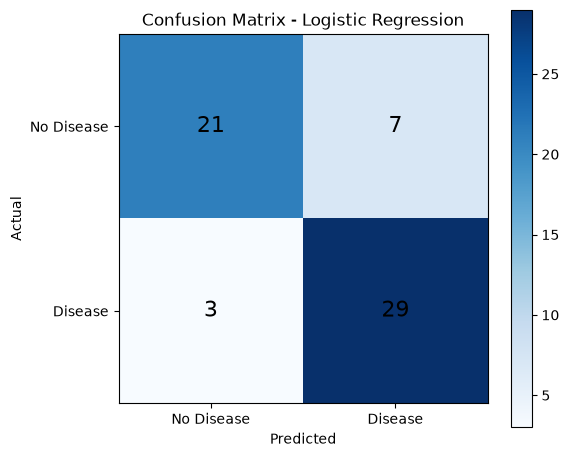

In [45]:
cm = confusion_matrix(y_test, y_pred_log_reg)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_yticklabels(['No Disease', 'Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Logistic Regression')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=16, color='black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
K_values = range(1,21)
accuracies = []

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)

    accuracies.append(accuracy_score(y_test, pred))

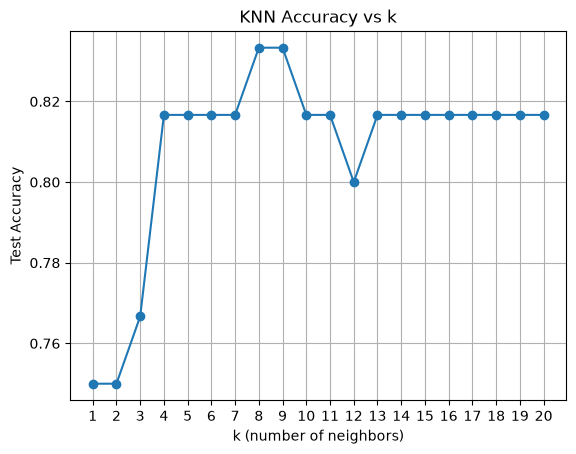

In [49]:
plt.plot(K_values, accuracies, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k')
plt.xticks(K_values)
plt.grid(True)
plt.show()

In [51]:
accuracies

[0.75,
 0.75,
 0.7666666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8333333333333334,
 0.8333333333333334,
 0.8166666666666667,
 0.8166666666666667,
 0.8,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667,
 0.8166666666666667]

In [52]:
knn_final = KNeighborsClassifier(n_neighbors=9)

In [53]:
knn_final.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [54]:
knn_final_pred = knn_final.predict(X_test_scaled)

In [55]:
accuracy_score(y_test,knn_final_pred)

0.8333333333333334

In [56]:
precision_score(y_test, knn_final_pred)

0.7894736842105263

In [57]:
recall_score(y_test,knn_final_pred)

0.9375

In [58]:
f1_score(y_test, knn_final_pred)

0.8571428571428571

In [59]:
confusion_matrix(y_test, knn_final_pred)

array([[20,  8],
       [ 2, 30]])

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [62]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [64]:
y_pred_rf = rf.predict(X_test)

In [65]:
accuracy_score(y_test, y_pred_rf)

0.7666666666666667

In [66]:
precision_score(y_test, y_pred_rf)

0.7368421052631579

In [67]:
recall_score(y_test, y_pred_rf)

0.875

In [68]:
f1_score(y_test, y_pred_rf)

0.8

In [69]:
confusion_matrix(y_test, y_pred_rf)

array([[18, 10],
       [ 4, 28]])

In [70]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances

thalach     0.122700
cp          0.122616
ca          0.115616
thal        0.115290
oldpeak     0.107091
chol        0.094673
age         0.083471
exang       0.063295
trestbps    0.059555
slope       0.056525
sex         0.029926
restecg     0.018952
fbs         0.010291
dtype: float64

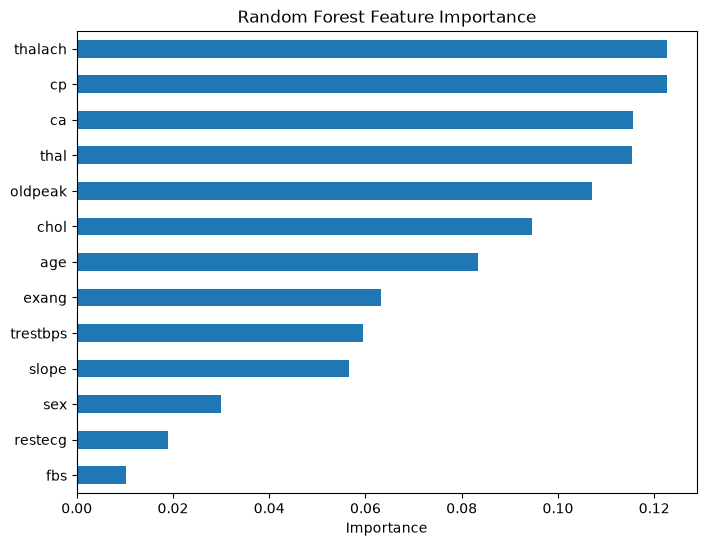

In [71]:
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [74]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [75]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [76]:
grid_search.best_params_

{'max_depth': 3,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 100}

In [77]:
grid_search.best_score_

np.float64(0.8601063829787234)

In [78]:
best_rf = grid_search.best_estimator_

In [79]:
y_pred_best_rf = best_rf.predict(X_test)

In [80]:
accuracy_score(y_test, y_pred_best_rf)

0.8166666666666667

In [81]:
precision_score(y_test, y_pred_best_rf)

0.7692307692307693

In [82]:
recall_score(y_test, y_pred_best_rf)

0.9375

In [83]:
f1_score(y_test, y_pred_best_rf)

0.8450704225352113

In [84]:
confusion_matrix(y_test, y_pred_best_rf)

array([[19,  9],
       [ 2, 30]])

In [85]:
models = ['Logistic\nRegression', 'KNN', 'Random\nForest (tuned)']
accuracy_vals = [0.833, 0.833, 0.817]
precision_vals = [0.806, 0.789, 0.769]
recall_vals = [0.906, 0.938, 0.938]
f1_vals = [0.853, 0.857, 0.845]

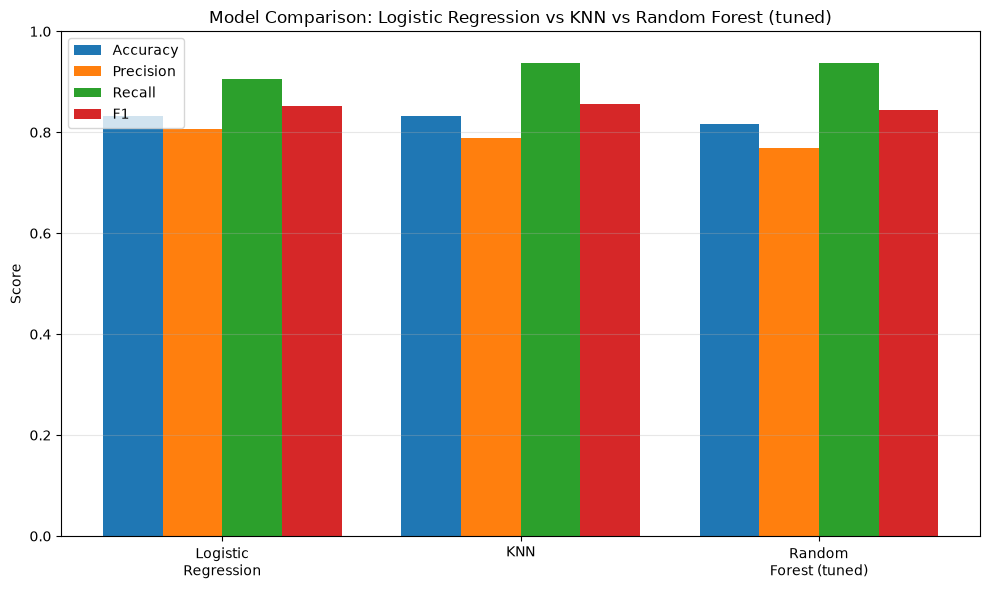

In [86]:
x = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 1.5*width, accuracy_vals, width, label='Accuracy')
ax.bar(x - 0.5*width, precision_vals, width, label='Precision')
ax.bar(x + 0.5*width, recall_vals, width, label='Recall')
ax.bar(x + 1.5*width, f1_vals, width, label='F1')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison: Logistic Regression vs KNN vs Random Forest (tuned)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
import joblib

In [88]:
joblib.dump(knn_final, 'knn_heart_disease_model.pkl')


['knn_heart_disease_model.pkl']

In [89]:
joblib.dump(scaler, 'heart_disease_scaler.pkl')

['heart_disease_scaler.pkl']

In [90]:
loaded_model = joblib.load('knn_heart_disease_model.pkl')
loaded_scaler = joblib.load('heart_disease_scaler.pkl')

In [91]:
test_pred = loaded_model.predict(loaded_scaler.transform(X_test))
accuracy_score(y_test, test_pred)

0.8333333333333334